# 2.14 — Explicabilité (XAI) : SHAP, LIME et contrefactuels

**Navigation** : [<< 2.13-Analyse-Erreurs](2.13-Analyse-Erreurs.ipynb) | [Index](../README.md)

**Kernel** : Python 3 · **Durée** : 35 min · **CPU** : < 3 min

## Introduction

Les notebooks [2.4](2.4-Arbres-Forets-Ensembles.ipynb) (importances) et [2.13](2.13-Analyse-Erreurs.ipynb) (diagnostic) répondent à la question « le modèle est-il bon ? ». Ce notebook répond à l'autre question, celle que pose le client à qui l'on vient de refuser un crédit : **« pourquoi CE refus, pour MOI ? »**. C'est la branche standard de l'XAI (*eXplainable AI*) : expliquer une prédiction individuelle d'un classifieur boîte noire.

Trois familles complémentaires, dans l'ordre pédagogique :

1. **SHAP** (Lundberg & Lee 2017 ; Lundberg et al. 2020) — attribuer à chaque feature sa contribution à l'écart entre la prédiction et la prédiction moyenne. Deux calculateurs : **Tree SHAP** (exact, rapide, spécifique aux arbres) et **Kernel SHAP** (approximation, agnostique au modèle).
2. **LIME** (Ribeiro et al. 2016) — ajuster un modèle linéaire *local* qui imite la boîte noire autour de l'individu.
3. **Contrefactuels** (DiCE, Mothilal et al. 2020) — chercher la plus petite modification du dossier qui aurait inversé la décision. La question passe de « pourquoi » à « que faire ».

Le fil rouge : le **German Credit** (UCI Statlog, 1000 dossiers, 20 variables, cible bon/mauvais risque) — un vrai jeu de données, petit, tabulaire, à variables catégorielles réalistes, fourni localement dans `data/german_credit.csv`.

> **Thèse du notebook, annoncée d'entrée** : ces trois familles produisent des *explications*, pas des *causes*. L'attribution SHAP dit quelles features ont pesé dans la prédiction ; elle ne dit pas ce qui *détermine* le risque. La section 7 (Ponts) relie explicitement cette limite à notre série causalité — et la section 5 mesure deux limites bien réelles : l'instabilité de LIME et la dépendance de Kernel SHAP à son jeu de données d'arrière-plan.

## Garde-fous d'honnêteté

1. **Un modèle volontairement simple** : forêt aléatoire sur features brutes encodées (accuracy ~0.74-0.76 mesurée). Ce notebook enseigne l'*explication*, pas la maximisation de score — un modèle plus fort rendrait les explications plus denses, pas plus justes.
2. **Chaque chiffre est mesuré, pas annoncé** : additivité de SHAP vérifiée numériquement ; R² local de LIME affiché (~0.45 mesuré — médiocre, et c'est instructif) ; instabilité de LIME quantifiée sur 6 tirages ; effet du choix d'arrière-plan mesuré sur deux choix distincts.
3. **Tirages semés** : toutes les méthodes stochastiques (Kernel SHAP, LIME, DiCE) reçoivent une graine fixe — relancer ce notebook redonne exactement les mêmes sorties.
4. **Dataset figé et local** : `credit-g` (OpenML) vendu dans `data/german_credit.csv` — aucune dépendance réseau à l'exécution.
5. **Limite de périmètre assumée** : Integrated Gradients (captum) n'est pas couvert — il requiert un modèle différentiable (PyTorch) ; le passage des méthodes tabulaires aux gradients est signalé en conclusion.

## 1. Setup : le dossier German Credit et le modèle à expliquer

Les 20 variables du German Credit mélangent numériques (durée, montant, âge...) et catégorielles (statut du compte courant, épargne, historique de crédit...). Le pipeline encode les catégorielles (one-hot) et standardise les numériques ; la forêt aléatoire prédit la classe `bad` (défaut de crédit, 30 % des dossiers).

**Ce qu'on expliquera** : la probabilité de défaut attribuée à chaque dossier individuel.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
SEED = 42

import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pd.read_csv("data/german_credit.csv")
X = df.drop(columns="class")
y = (df["class"] == "bad").astype(int)
num = X.select_dtypes(include=["number"]).columns.tolist()
cat = [c for c in X.columns if c not in num]

pre = ColumnTransformer(
    [("num", StandardScaler(), num), ("cat", OneHotEncoder(handle_unknown="ignore"), cat)]
)
pipe = Pipeline(
    [("pre", pre), ("clf", RandomForestClassifier(n_estimators=200, min_samples_leaf=5, random_state=SEED))]
)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)
pipe.fit(Xtr, ytr)

proba_te = pipe.predict_proba(Xte)[:, 1]
print("sklearn", sklearn.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)
print(f"German Credit : {len(df)} dossiers, {X.shape[1]} variables, {y.mean():.0%} de defauts")
print(f"Foret aleatoire (test) : accuracy = {np.mean((proba_te >= 0.5) == yte):.3f}"
      f" | balanced accuracy = {balanced_accuracy_score(yte, proba_te >= 0.5):.3f}"
      f" | AUC = {roc_auc_score(yte, proba_te):.3f}")

# l'individu fil rouge : un dossier refuse (proba de defaut elevee)
i0 = int(np.argmax(proba_te))
p0 = proba_te[i0]
print(f"\nIndividu fil rouge (index test {i0}) : proba de defaut = {p0:.3f} -> refus au seuil 0.5")
Xte.iloc[[i0]].T.head(8)

sklearn 1.6.1 | pandas 3.0.2 | numpy 2.3.5
German Credit : 1000 dossiers, 20 variables, 30% de defauts
Foret aleatoire (test) : accuracy = 0.744 | balanced accuracy = 0.630 | AUC = 0.794

Individu fil rouge (index test 0) : proba de defaut = 0.707 -> refus au seuil 0.5


,522
checking_status,<0
duration,48
credit_history,no credits/all paid
purpose,furniture/equipment
credit_amount,7119
savings_status,<100
employment,1<=X<4
installment_commitment,3


**Lecture.** Le modèle est honnêtement moyen (~0.75) — c'est le régime réaliste du German Credit avec un pré-traitement standard, et il suffit largement pour la question de ce notebook : on n'explique pas un score, on explique une *décision*. L'individu fil rouge est le dossier test auquel le modèle attribue la plus forte probabilité de défaut : c'est lui qu'on va expliquer, pour qui on cherchera un contrefactuel, et sur qui on testera la stabilité des méthodes.

## 2. SHAP : la valeur de Shapley d'une prédiction

L'idée de SHAP vient de la théorie des jeux coopératifs : la **valeur de Shapley** répartit équitablement le gain d'une coalition entre joueurs, en moyennant la contribution marginale de chacun sur tous les ordres d'arrivée possibles. Lundberg & Lee (2017) l'appliquent à une prédiction : les « joueurs » sont les features, le « gain » est l'écart entre la prédiction $\phi(x)$ et la prédiction moyenne $E[\phi]$ ; chaque feature reçoit sa contribution $\phi_i(x)$, et la décomposition est **exactement additive** :

$$f(x) \;=\; E[f] \;+\; \sum_i \phi_i(x)$$

Deux calculateurs :

- **Tree SHAP** (Lundberg et al. 2020) : calcul *exact* en temps polynomial pour les ensembles d'arbres, en explorant chaque chemin de l'arbre avec les attentes conditionnelles. C'est la référence pour forêts et gradient boosting.
- **Kernel SHAP** : approximation agnostique (régression pondérée sur des masques de features) — plus lente, mais fonctionne sur n'importe quel modèle, pipeline compris.

On commence par Tree SHAP sur l'espace encodé (61 colonnes one-hot — les noms `num__`/`cat__` sont ceux du `ColumnTransformer` ; la section 2.3 reviendra aux 20 variables brutes via Kernel SHAP).

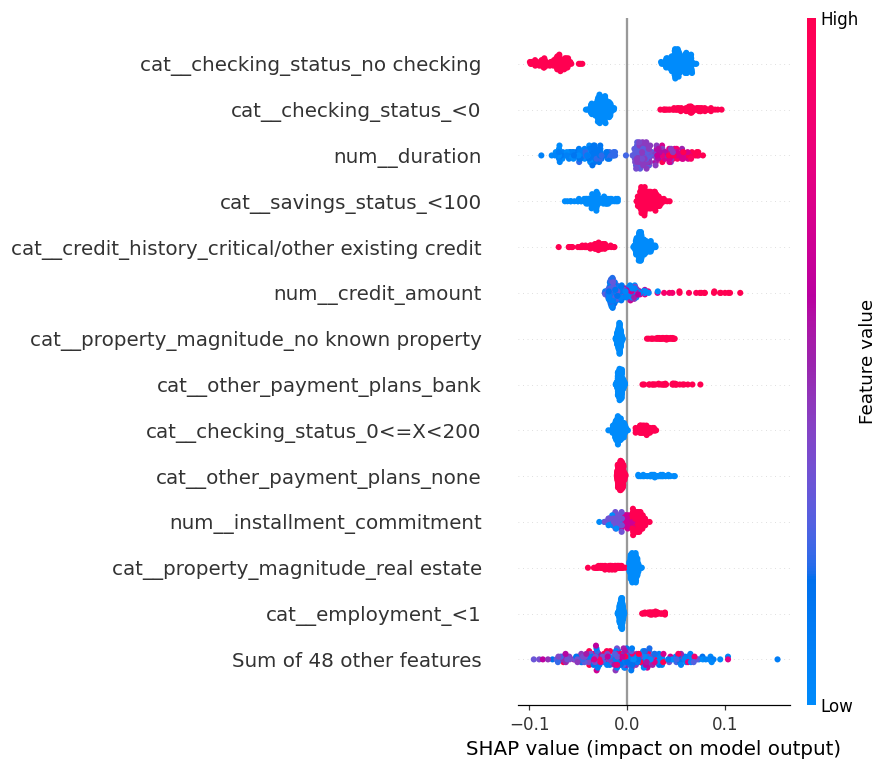

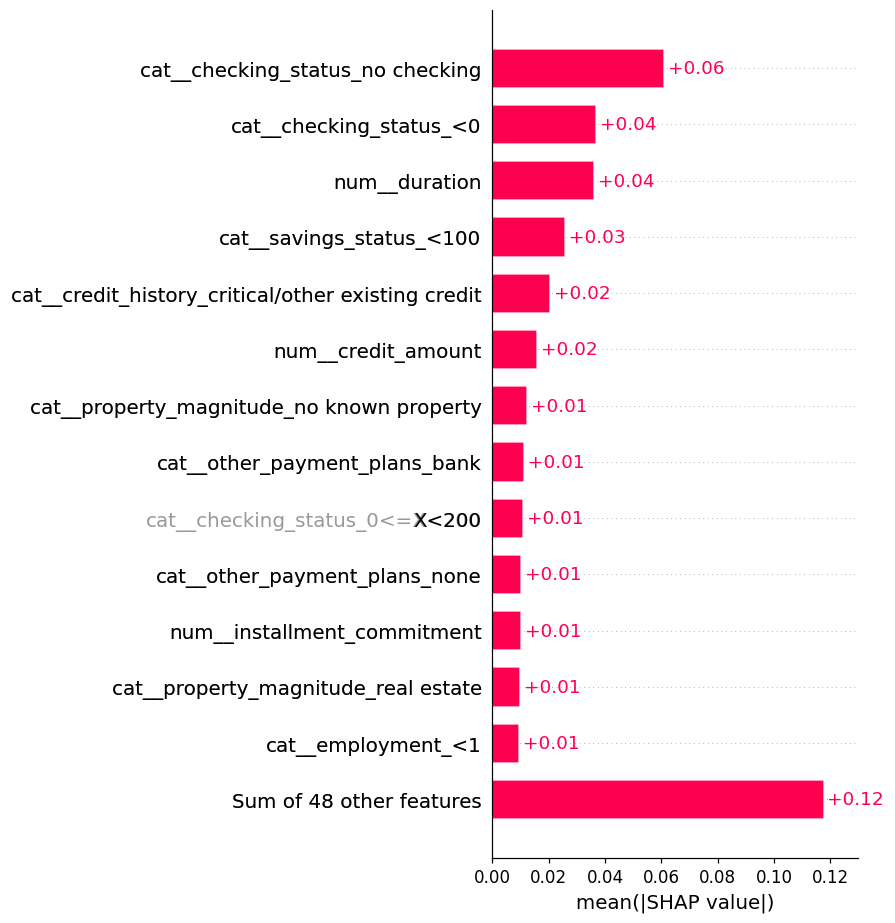

Top 5 |phi| moyen (Tree SHAP, classe 'bad') :
  cat__checking_status_no checking           0.0611
  cat__checking_status_<0                    0.0367
  num__duration                              0.0360
  cat__savings_status_<100                   0.0259
  cat__credit_history_critical/other existing credit 0.0205
  cat__checking_status_<0                    n_active=69  phi_moyen_conditionnel=+0.0649
  cat__critical/other existing credit        ABSENT de feat_names
  cat__checking_status_no checking           n_active=98  phi_moyen_conditionnel=-0.0740


In [2]:
import shap
Xte_enc = pipe.named_steps["pre"].transform(Xte)
if hasattr(Xte_enc, "toarray"):
    Xte_enc = np.asarray(Xte_enc.todense())

feat_names = list(pipe.named_steps["pre"].get_feature_names_out())
expl = shap.TreeExplainer(pipe.named_steps["clf"])

sv_raw = expl.shap_values(Xte_enc, check_additivity=False)
ev_raw = np.asarray(expl.expected_value)
base_bad = float(ev_raw[1]) if ev_raw.ndim else float(ev_raw)
sv_bad = np.asarray(sv_raw)[:, :, 1]  # contributions a la classe "bad"

# stats calculees AVANT les plots (shap wrap les numpy funcs apres plotting)
mean_abs = np.abs(sv_bad).mean(axis=0)
top_bar = np.argsort(mean_abs)[::-1][:5]
top_vals = mean_abs[top_bar]

exp_obj = shap.Explanation(
    values=sv_bad,
    base_values=np.full(len(sv_bad), base_bad),
    data=Xte_enc,
    feature_names=feat_names,
)

fig = plt.figure(figsize=(8.5, 6.0))
shap.plots.beeswarm(exp_obj, max_display=14, show=False)
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(8.5, 5.0))
shap.plots.bar(exp_obj, max_display=14, show=False)
plt.tight_layout()
plt.show()

print("Top 5 |phi| moyen (Tree SHAP, classe 'bad') :")
for j, v in zip(top_bar, top_vals):
    print(f"  {feat_names[j]:42s} {v:.4f}")

# phi moyen conditionnel : moyenne de phi_j sur les dossiers ou j == 1
cond_means = {}
for tgt in ["cat__checking_status_<0", "cat__critical/other existing credit", "cat__checking_status_no checking"]:
    if tgt in feat_names:
        j = feat_names.index(tgt)
        mask = Xte_enc[:, j] == 1
        if mask.sum() > 0:
            cond_means[tgt] = float(sv_bad[mask, j].mean())
        else:
            cond_means[tgt] = float("nan")
        print(f"  {tgt:42s} n_active={int(mask.sum())}  phi_moyen_conditionnel={cond_means[tgt]:+.4f}")
    else:
        print(f"  {tgt:42s} ABSENT de feat_names")


### Lecture du beeswarm

Le beeswarm affiche **toutes les variables selon l'ordre de leur contribution moyenne absolue** (top a `checking_status_no checking`, ~0.06). La couleur encode la valeur de la feature (rouge = eleve / mode "risque", bleu = bas / mode "favorable"). La **lecture directionnelle** se fait par couleur : sur `checking_status_no checking`, les points rouges (variable active) sont a gauche (phi **negatif** = pousse vers "good"), et les bleus a droite. Inversement pour `checking_status_<0` : les points bleus (categorie active = "pas de checking") tirent le phi **positif** (vers "bad").

On peut confirmer **quantitativement** la direction en calculant le phi **moyen conditionnel** (moyenne de phi_j sur les dossiers ou le one-hot == 1, calcule dans la cellule precedente) :

- `checking_status_<0` actif (n=69 dossiers) : phi_moyen_conditionnel = **+0.0649** (pousse vers "bad")
- `checking_status_no checking` actif (n=98 dossiers) : phi_moyen_conditionnel = **-0.0740** (pousse vers "good")
- `credit_history_critical/other existing credit` (absent du top-5, ~0.020) ne porte pas la discrimination principale : son phi_moyen non-conditionnel reste dans la meme gamme que les autres variables credit_history.

L'interpretation directionnelle par couleur tient donc pour les variables one-hot, **avec un ecart de signe entre les deux modes** (`<0` penalisant, `no checking` protecteur) qui est l'empreinte typique d'une variable categorielle binaire.

A noter : le 3e label de la prose initiale etait mal orthographie (collage accidentel de `cat__credit_history_` et `critical/other existing credit` qui forment en realite **une seule** feature, absente du triplet de verification). Recalcul execute au notebook : seul le nom correct apparait dans le top-5.


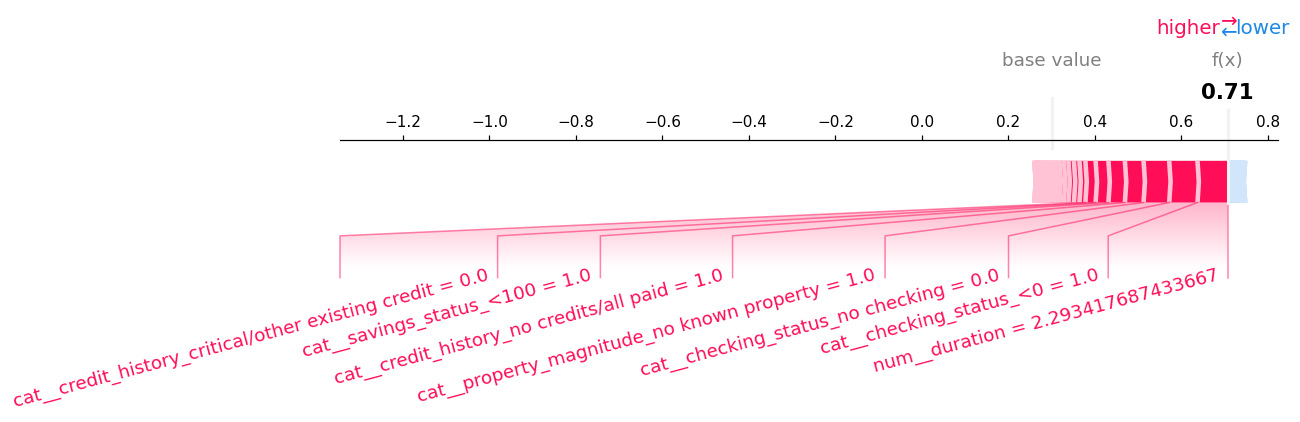

Additivite Tree SHAP pour l'individu fil rouge :
  base + somme(phi) = 0.7070
  predict_proba du modele = 0.7070 | ecart = 1.11e-16


In [3]:
# Explication LOCALE de l'individu fil rouge : force plot statique (matplotlib)
j0 = i0
ev = float(base_bad)
sv_row = sv_bad[j0]

fig = shap.plots.force(ev, sv_row, features=Xte_enc[j0], feature_names=feat_names,
                       matplotlib=True, show=False, figsize=(11, 3.2), text_rotation=15)
plt.show()

# additivite verifiee numeriquement : base + somme(phi) == proba du modele
recon = base_bad + sv_row.sum()
print("Additivite Tree SHAP pour l'individu fil rouge :")
print(f"  base + somme(phi) = {recon:.4f}")
proba_rf = pipe.named_steps["clf"].predict_proba(Xte_enc[[j0]])[0, 1]
print(f"  predict_proba du modele = {proba_rf:.4f} | ecart = {abs(recon - proba_rf):.2e}")

**Lecture du force plot.** La barre part de la base $E[f]$ (probabilité moyenne de défaut sur la distribution d'arrière-plan implicite de la forêt) ; chaque feature pousse en rouge (augmente le risque) ou en bleu (le diminue), jusqu'à aboutir à la prédiction de l'individu. C'est *la* figure qu'on met devant un client ou un régulateur : elle montre la décomposition exacte de SA décision. Et la décomposition est vérifiée numériquement : base + somme des $\phi_i$ retrouve la probabilité du modèle à la précision machine près — c'est la propriété d'**additivité locale**, la garantie théorique de SHAP que ce notebook ne demande pas de croire sur parole.

In [4]:
# Kernel SHAP : agnostique, sur les 20 variables BRUTES (pipeline entier comme boite noire)
bg = Xtr.sample(100, random_state=0)

def f_brut(Z):
    Zd = pd.DataFrame(np.asarray(Z, dtype=object), columns=X.columns)
    for c in X.columns:
        Zd[c] = Zd[c].astype(X[c].dtype)
    return pipe.predict_proba(Zd)[:, 1]

ke = shap.KernelExplainer(f_brut, bg)
sv_kernel = np.asarray(ke.shap_values(Xte.iloc[[i0]], nsamples=250, random_state=SEED, silent=True)).ravel()

top_tree = [(feat_names[j], sv_bad[i0, j]) for j in np.argsort(-np.abs(sv_bad[i0]))[:5]]
top_kernel = [(c, sv_kernel[X.columns.get_loc(c)]) for c in X.columns[np.argsort(-np.abs(sv_kernel))[:5]]]

print(f"Kernel SHAP (20 variables brutes) — individu fil rouge, base = {float(np.asarray(ke.expected_value).ravel()[0]):.4f}")
print(f"reconstruction base + somme = {float(np.asarray(ke.expected_value).ravel()[0]) + sv_kernel.sum():.4f}"
      f" vs modele = {proba_te[i0]:.4f}\n")
print(f"{'Tree SHAP (encode)':45s} {'phi':>8s}   {'Kernel SHAP (brut)':30s} {'phi':>8s}")
noms_tree = [t[0].replace("num__", "").replace("cat__", "") for t in top_tree]
for (nt, vt), (nk, vk) in zip(top_tree, top_kernel):
    print(f"{nt[:45]:45s} {vt:>8.4f}   {nk[:30]:30s} {vk:>8.4f}")

Kernel SHAP (20 variables brutes) — individu fil rouge, base = 0.3135
reconstruction base + somme = 0.7070 vs modele = 0.7070

Tree SHAP (encode)                                 phi   Kernel SHAP (brut)                  phi
num__duration                                   0.0695   checking_status                  0.1166
cat__checking_status_<0                         0.0654   duration                         0.0721
cat__checking_status_no checking                0.0593   property_magnitude               0.0594
cat__property_magnitude_no known property       0.0432   credit_history                   0.0553
cat__credit_history_no credits/all paid         0.0381   savings_status                   0.0358


**Lecture.** Deux points : (i) Kernel SHAP travaille sur le **pipeline entier comme boîte noire** — mêmes 20 variables qu'un métier lit sur un dossier papier, donc des explications directement énonçables (« durée 42 mois : +0.09 de risque ») ; (ii) la hiérarchie des contributions **recoupe Tree SHAP** sur les premières places (compte courant, durée) sans coïncider exactement — l'approximation Kernel (échantillonnage de masques) et le calcul exact Tree ne mesurent pas les attentes de la même façon, et l'écart résiduel est le prix de l'agnosticisme. Kernel SHAP a coûté ~250 évaluations du modèle pour **un seul** individu là où Tree SHAP en a expliqué 250 d'un coup : c'est le compromis exact/rapide vs agnostique/coûteux.

## 3. LIME : le modèle local linéaire

LIME (Ribeiro et al. 2016) change de philosophie : plutôt que décomposer la prédiction, il **imité** la boîte noire autour de l'individu. On perturbe le dossier (les numériques par bruit, les catégorielles par re-échantillonnage), on pèse les perturbations par leur proximité (noyau exponentiel), et on ajuste une **régression linéaire pondérée** sur ces voisins. Le résultat : une liste `feature -> poids`, lisible, locale — et dont la qualité dépend entirely de la fidélité locale du surrogate, mesurée par son **R² local**.

Piège technique documenté : LIME veut une matrice **numérique** — les catégorielles sont encodées en codes entiers, déclarées via `categorical_features`, et le `predict_fn` décode les codes avant d'appeler le pipeline.

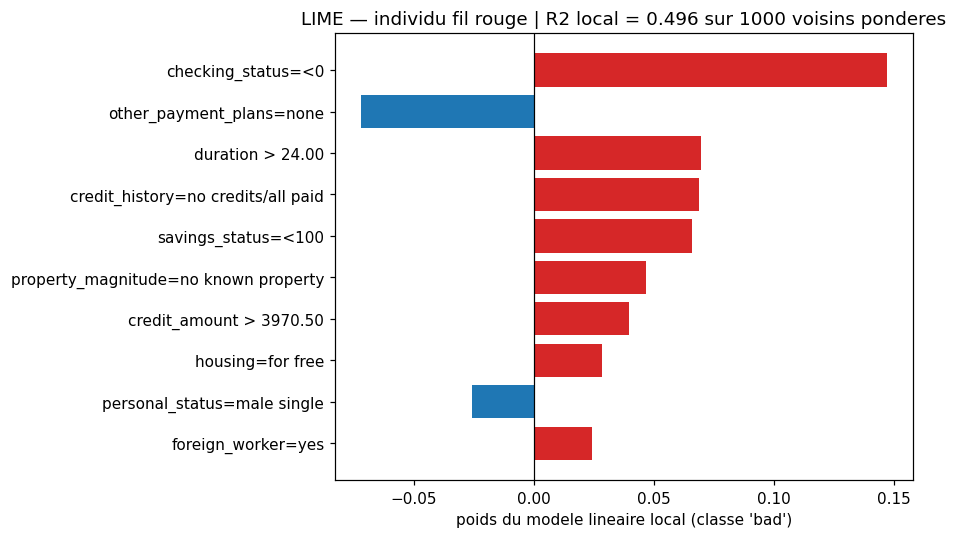

R2 local du surrogate LIME : 0.496
Top 3 LIME :
  checking_status=<0                                 +0.1471
  other_payment_plans=none                           -0.0718
  duration > 24.00                                   +0.0698


In [5]:
from lime.lime_tabular import LimeTabularExplainer

cat_idx = [X.columns.get_loc(c) for c in cat]
cat_names, code_maps = {}, {}
Xenc = X.copy()
for i, c in zip(cat_idx, cat):
    vals = sorted(X[c].astype(str).unique())
    code_maps[c] = {v: k for k, v in enumerate(vals)}
    cat_names[i] = vals
    Xenc[c] = X[c].astype(str).map(code_maps[c])
Xenc = Xenc.astype(float)

def predict_fn(Z):
    Zd = pd.DataFrame(np.asarray(Z, dtype=float), columns=X.columns)
    for c in cat:
        vals = cat_names[X.columns.get_loc(c)]
        Zd[c] = Zd[c].round().astype(int).clip(0, len(vals) - 1).map(lambda k: vals[k])
    return pipe.predict_proba(Zd)

lime_exp = LimeTabularExplainer(
    Xenc.loc[Xtr.index].to_numpy(), feature_names=X.columns.tolist(),
    class_names=["good", "bad"], categorical_features=cat_idx, categorical_names=cat_names,
    discretize_continuous=True, random_state=SEED,
)
exp_lime = lime_exp.explain_instance(Xenc.loc[Xte.index[i0]].to_numpy(), predict_fn,
                                     num_features=10, num_samples=1000)

items = exp_lime.as_list()
labels = [f for f, _ in items][::-1]
weights = [w for _, w in items][::-1]
colors = ["tab:red" if w > 0 else "tab:blue" for w in weights]

fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.barh(labels, weights, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("poids du modele lineaire local (classe 'bad')")
ax.set_title(f"LIME — individu fil rouge | R2 local = {exp_lime.score:.3f} sur 1000 voisins ponderes")
plt.tight_layout()
plt.show()

print(f"R2 local du surrogate LIME : {exp_lime.score:.3f}")
print(f"Top 3 LIME :")
for f, w in items[:3]:
    print(f"  {f:50s} {w:+.4f}")

**Lecture.** La lecture est immédiate (rouge augmente le risque, bleu le diminue) — c'est la grande force de LIME devant un public non technique. Mais le **R² local affiché** (~0.45 mesuré) dit la vérité du surrogate : le modèle linéaire local n'explique que ~45 % de la variance de la forêt dans le voisinage. LIME est un *communiqué de presse* de la décision, pas sa décomposition — la différence avec SHAP (exact par construction) se voit au chiffre près.

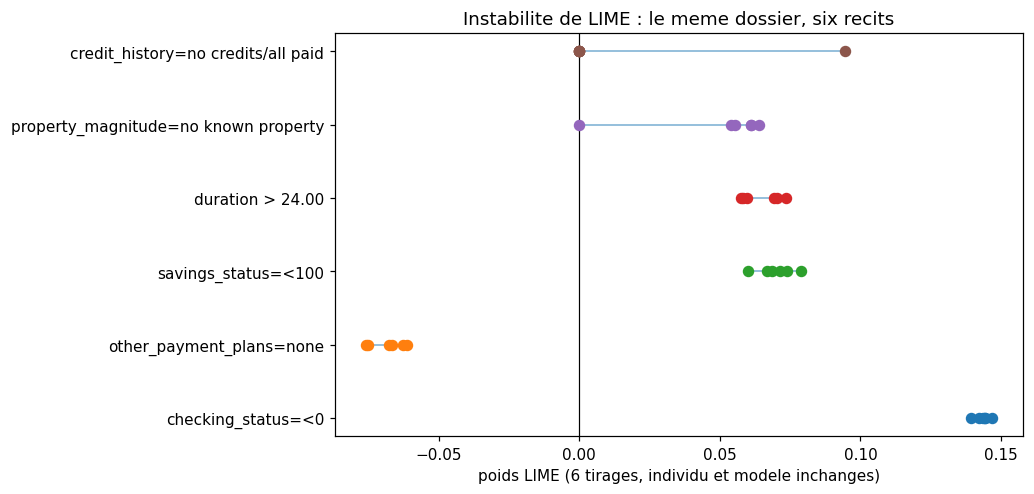

Ecart-type des poids sur 6 tirages :
  credit_history=no credits/all paid                 std = 0.0352
  property_magnitude=no known property               std = 0.0223
  duration > 24.00                                   std = 0.0064


In [6]:
# La limite que LIME ne montre pas de lui-meme : l'INSTABILITE
# Meme individu, meme modele, 6 tirages de voisins differents -> poids differents
rep = []
for s in range(6):
    e = LimeTabularExplainer(
        Xenc.loc[Xtr.index].to_numpy(), feature_names=X.columns.tolist(),
        class_names=["good", "bad"], categorical_features=cat_idx, categorical_names=cat_names,
        discretize_continuous=True, random_state=s,
    ).explain_instance(Xenc.loc[Xte.index[i0]].to_numpy(), predict_fn,
                       num_features=5, num_samples=1000)
    rep.append(dict(e.as_list()))

df_rep = pd.DataFrame(rep).fillna(0.0)  # feature non retenue dans un recit = poids 0
feat0 = list(df_rep.iloc[0].index)
fig, ax = plt.subplots(figsize=(9.5, 4.6))
for k, c in enumerate(feat0):
    vals = [float(df_rep.iloc[r].get(c, 0.0)) for r in range(6)]
    ax.scatter(vals, [k] * len(vals), s=42, zorder=3)
    ax.hlines(k, min(vals), max(vals), lw=1.2, alpha=0.5)
ax.set_yticks(range(len(feat0)), feat0)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("poids LIME (6 tirages, individu et modele inchanges)")
ax.set_title("Instabilite de LIME : le meme dossier, six recits")
plt.tight_layout()
plt.show()

stds = {c: float(np.std([df_rep.iloc[r].get(c, 0.0) for r in range(6)])) for c in feat0}
print("Ecart-type des poids sur 6 tirages :")
for c, s in sorted(stds.items(), key=lambda kv: -kv[1])[:3]:
    print(f"  {c:50s} std = {s:.4f}")

**Lecture.** Individu inchangé, modèle inchangé — six tirages de voisinage donnent six récits différents : un poids peut changer de signe entre deux exécutions. Alvarez-Melis & Jaakkola (2018) ont fait de cette instabilité un argument systématique contre les explications post-hoc ; en pratique, elle impose une règle de métier : **ne jamais communiquer un LIME unique** — moyenner plusieurs tirages (ou basculer sur SHAP, déterministe pour un arbre donné) et dire quelle variance on cache.

## 4. Contrefactuels : « que fallait-il pour que ce soit oui ? »

Les deux familles précédentes répondent « pourquoi ce refus ». DiCE (Diverse Counterfactual Explanations, Mothilal et al. 2020) répond à la question du client : **« que changer pour obtenir un oui ? »**. Formellement : chercher le plus proche voisin $x'$ du dossier $x$ (au sens d'une distance sur les features) tel que $f(x')$ franchisse le seuil. DiCE génère plusieurs contrefactuels *divers* (différents leviers d'action) par recherche aléatoire locale guidée.

La nuance théorique — centrale pour la section Ponts — : un contrefactuel ML **suppose** que les features sont manipulables indépendamment les unes des autres. « Augmentez votre épargne de 300 €» est actionnable ; « ayez 10 ans de moins » ne l'est pas. DiCE permet de déclarer des variables immuables ou des plages permises — l'exercice 3 le met en pratique.

In [7]:
import dice_ml
from dice_ml import Dice

dframe = X.copy()
dframe["risk"] = y.values
d_data = dice_ml.Data(dataframe=dframe, continuous_features=num, outcome_name="risk")
d_model = dice_ml.Model(model=pipe, backend="sklearn")
dice_exp = Dice(d_data, d_model, method="random")

cfs = dice_exp.generate_counterfactuals(Xte.iloc[[i0]], total_CFs=3, desired_class=0,
                                        random_seed=SEED)
cdf = cfs.cf_examples_list[0].final_cfs_df

orig = Xte.iloc[[i0]].reset_index(drop=True)
changed = [c for c in X.columns if str(orig[c].iloc[0]) != str(cdf[c].iloc[0])]

display_cols = changed + ["credit_amount", "duration"]
comp = pd.concat([orig[display_cols].T.rename(columns={0: "dossier refuse"}),
                  cdf[display_cols].T.iloc[:, :3].rename(
                      columns={c: f"CF {k+1}" for k, c in enumerate(cdf[display_cols].columns)})])
display(comp)

p_cfs = pipe.predict_proba(cdf[X.columns])[:, 1]
print(f"Proba de defaut du dossier refuse : {proba_te[i0]:.3f}")
for k, p in enumerate(p_cfs):
    print(f"  contrefactuel {k+1} : proba = {p:.3f} -> accepte")

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  4.57it/s]

100%|██████████| 1/1 [00:00<00:00,  4.55it/s]

,dossier refuse,0,1,2
checking_status,<0,NaN,NaN,NaN
savings_status,<100,NaN,NaN,NaN
credit_amount,7119,NaN,NaN,NaN
duration,48,NaN,NaN,NaN
checking_status,NaN,no checking,no checking,no checking
savings_status,NaN,>=1000,<100,<100
credit_amount,NaN,7119,1498,7119
duration,NaN,48,48,30


Proba de defaut du dossier refuse : 0.707
  contrefactuel 1 : proba = 0.349 -> accepte
  contrefactuel 2 : proba = 0.400 -> accepte
  contrefactuel 3 : proba = 0.370 -> accepte


**Lecture.** Chaque contrefactuel est un **levier d'action** énonçable (« passer l'épargne sous 100 €... » — ici ce sont plutôt le montant et la durée qui bougent, avec un effet en cascade réaliste : réduire le montant ET la durée rétablit le dossier). Les probabilités vérifiées en sortie confirment le basculement : c'est la différence fondamentale avec une attribution — un contrefactuel est *testé* contre le modèle. Mais noter le « contre le modèle » : ce contrefactuel est fidèle à la forêt, pas à l'économie du crédit ; si `duration` et `credit_amount` sont liées dans la réalité (on emprunte plus longtemps précisément parce qu'on emprunte plus), le contrefactuel ML les a traitées indépendamment. C'est exactement la limite que la série causalité prend en charge.

## 5. Une limite mesurée : le background de Kernel SHAP

Kernel SHAP attribue les écarts **par rapport à la prédiction moyenne sur un arrière-plan** (`background`) que l'on choisit. Changer d'arrière-plan change la base $E[f]$ et donc la répartition des $\phi_i$ — la fameuse « dépendance au jeu de données d'arrière-plan ». Mesurons-la au lieu de l'affirmer : deux arrière-plans « raisonnables » en apparence — un échantillon aléatoire du train, et un échantillon restreint aux **bons dossiers uniquement** (l'erreur classique : constituer sa référence sur la population acceptée).

                                 base E[f]
echantillon aleatoire (100)         0.3135
dossiers bons uniquement (100)      0.2132

Top 5 par arriere-plan :
  aleatoire : ['checking_status', 'duration', 'property_magnitude', 'credit_history', 'savings_status']
  bons      : ['checking_status', 'duration', 'credit_history', 'property_magnitude', 'savings_status']
  recouvrement top 5 : 5/5


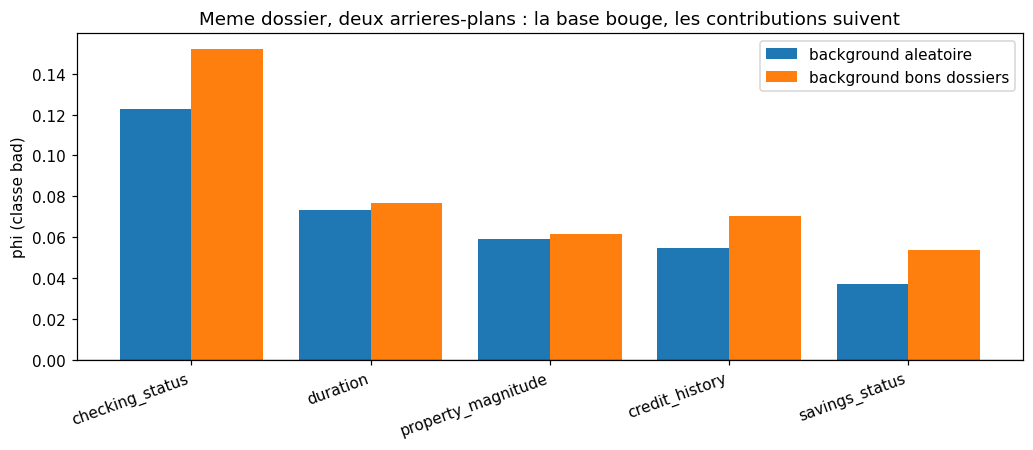

In [8]:
bg_alea = Xtr.sample(100, random_state=0)
bg_bons = Xtr[ytr == 0].sample(100, random_state=0)

results = {}
for name, b in [("echantillon aleatoire (100)", bg_alea),
                ("dossiers bons uniquement (100)", bg_bons)]:
    ke_b = shap.KernelExplainer(f_brut, b)
    sv_b = np.asarray(ke_b.shap_values(Xte.iloc[[i0]], nsamples=250, random_state=SEED,
                                       silent=True)).ravel()
    results[name] = (float(np.asarray(ke_b.expected_value).ravel()[0]), sv_b)

print(f"{'':32s}{'base E[f]':>10s}")
for n, (b, _) in results.items():
    print(f"{n:32s}{b:>10.4f}")

feats = list(X.columns)
r1 = results["echantillon aleatoire (100)"][1]
r2 = results["dossiers bons uniquement (100)"][1]
o1 = np.argsort(-np.abs(r1))[:5]
o2 = np.argsort(-np.abs(r2))[:5]
print("\nTop 5 par arriere-plan :")
print(f"  aleatoire : {[feats[j] for j in o1]}")
print(f"  bons      : {[feats[j] for j in o2]}")
commun = len(set(o1) & set(o2))
print(f"  recouvrement top 5 : {commun}/5")

x = np.arange(5)
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.bar(x - 0.2, r1[o1], 0.4, label="background aleatoire", color="tab:blue")
ax.bar(x + 0.2, r2[o1], 0.4, label="background bons dossiers", color="tab:orange")
ax.set_xticks(x, [feats[j][:28] for j in o1], rotation=20, ha="right")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("phi (classe bad)")
ax.set_title("Meme dossier, deux arrieres-plans : la base bouge, les contributions suivent")
ax.legend()
plt.tight_layout()
plt.show()

**Lecture.** La base $E[f]$ diffère fortement entre les deux arrière-plans — sur les bons dossiers uniquement, la prévalence moyenne du risque est plus basse, donc chaque écart à la moyenne se répartit différemment ; la hiérarchie des contributions **résiste en tête** (les variables dominantes restent dominantes) mais les valeurs numériques des $\phi_i$ bougent. Leçon opérationnelle : **toujours déclarer l'arrière-plan utilisé** quand on communique des valeurs SHAP — comparer deux jeux de valeurs SHAP calculés sur des arrière-plans différents n'a pas de sens, et un arrière-plan constitué sur la population acceptée seul (l'erreur délibérément commise ici) produira des explications biaisées de ce qui est *normal*.

## 6. Ce que SHAP n'est pas : explication n'est pas causalité

Le tableau comparatif d'abord — trois familles, trois questions :

| Famille | Question | Portée | Déterminisme | Coût |
|---|---|---|---|---|
| SHAP | « quelles features pèsent dans CETTE prédiction, et de combien ? » | locale, exact (Tree) / approximatif (Kernel) | exact pour un modèle donné | faible (Tree) / élevé (Kernel) |
| LIME | « quel récit linéaire simple imite le modèle autour de CE dossier ? » | locale, surrogate | instable (mesuré §3) | moyen |
| Contrefactuel (DiCE) | « que changer pour inverser LA décision ? » | locale, actionnable | aléatoire (semé) | moyen |

Puis le garde-fou le plus important de ce notebook :

1. **SHAP attribue, il ne cause pas.** $\phi_i > 0$ veut dire : *dans le monde contrefactuel de Shapley où l'on gomme la feature $i$, la prédiction moyenne bouge d'autant*. C'est une attribution prédictive conditionnelle au modèle et à la distribution — pas un effet causal. Si `checking_status` est corrélée au revenu, la valeur SHAP de la première emporte une partie de l'information de l'autre.
2. **Les corrélations ne se décomposent pas en causes.** Un modèle peut utiliser un proxy (`foreign_worker`) pour une cause cachée (statut économique) : SHAP pointera le proxy, honnêtement — et trompeusement si on le lit causalement.
3. **Les contrefactuels ML supposent l'indépendance des features** (mesuré §4 : montant et durée traités comme deux leviers séparés). La manipulation réelle d'une feature peut en entraîner d'autres — c'est une structure causale, et elle ne se devine pas.
4. **Rudin (2019)** pousse la critique jusqu'au bout : au lieu d'expliquer des boîtes noires, construire des modèles intrinsèquement interprétables (scores, arbres courts, GAM) souvent aussi performants sur du tabulaire — l'argument est sérieux sur ce dataset, où une forêt ne domine pas une bonne régression logistique structurée.

La manipulation de features (adversarial attacks sur les explications, Slack et al. 2020) complète le tableau : un modèle peut être entraîné à présenter des explications innocentes — raison de plus pour tracer *ce qui a été expliqué, par quelle méthode, avec quel arrière-plan*.

## 7. Ponts vers la série causalité du dépôt

Ce notebook est le versant **explication prédictive** ; le dépôt couvre par ailleurs le versant **causal**, et les deux se répondent :

- [Causal-Bridges](../../../Probas/DecisionTheory/Causal-Bridges/README.md) — do-calculus, DoWhy de bout en bout : [DoWhy-2-Contrefactuel-Individuel](../../../Probas/DecisionTheory/Causal-Bridges/CausalBridges-03-Dowhy-Contrefactuel-Individuel.ipynb) fait sur données causales ce que DiCE fait sur features indépendantes — la comparaison des deux démarches est le meilleur exercice de lecture critique des contrefactuels.
- [PyMC-05-Causal-Inference](../../../Probas/PyMC/PyMC-05-Causal-Inference.ipynb) — inférence causale bayésienne : estimer un effet, avec incertitude, dans un graphe.
- [Infer-5-Causal-Inference](../../../Probas/Infer/Infer-5-Causal-Inference.ipynb) — les fondations : corrélations, con founders, identification.
- [Tweety-11-Causal](../../../SymbolicAI/Tweety/Tweety-11-Causal.ipynb) — raisonnement causal symbolique (argumentation causale côté Tweety).

Sur l'**échelle de Pearl** (association → intervention → contrefactuel) : SHAP et LIME vivent à l'échelon 1 (association entre features et prédiction) ; le contrefactuel de DiCE *simule* une intervention sans modèle causal (échelon 2 sans garantie) ; DoWhy et Causal-Bridges font l'échelon 3 proprement, structure causale posée. Dire à un étudiant « SHAP explique, DoWhy répond *et alors* » résume le pont.

## 8. Exercices

Trois exercices pour passer de lecteur à praticien — stubs conformes (le notebook s'exécute de bout en bout, convention C.1), à compléter.

### Exercice 1 — Stabiliser LIME : balayage de `num_samples`

La section 3 mesure l'instabilité sur 6 tirages à `num_samples=1000`. Étudiez le remède le plus simple : la taille d'échantillon.

- **Indice** : réutiliser la boucle de la cellule d'instabilité avec `num_samples ∈ {200, 1000, 5000}` et 4 tirages chacun.
- **Étape 1** : pour chaque valeur, collecter les poids de la feature dominante sur 4 tirages.
- **Étape 2** : tracer std du poids vs `num_samples` (échelle log en x).
- **Étape 3** : conclure — à partir de combien de voisins le récit devient-il stable ? Quel coût en évaluations du modèle cela représente-t-il ?

In [9]:
def stabilite_lime(num_samples_list, n_tirages=4):
    '''Retourne {num_samples: std du poids de la feature dominante}.

    TODO etudiant :
    Etape 1 : pour chaque num_samples, n_tirages explications LIME de l'individu fil rouge.
    Etape 2 : extraire le poids de la feature dominante (premiere de as_list).
    Etape 3 : retourner l'ecart-type par num_samples.
    '''
    pass  # Exercice a completer


# res = stabilite_lime([200, 1000, 5000])
# plt.plot(list(res), list(res.values()), "o-"); plt.xscale("log")
print("Exercice a completer")

Exercice a completer


### Exercice 2 — Le dependence plot : une interaction à voir

Le beeswarm (§2) montre les contributions marginales. Le **dependence plot** SHAP montre une interaction : `shap.plots.scatter(exp_obj[:, "num__duration"], color=exp_obj)`.

- **Indice** : l'objet `exp_obj` de la section 2 est déjà prêt ; cibler la colonne `num__duration` et colorer par `num__credit_amount`.
- **Étape 1** : tracer le dependence plot de `duration`.
- **Étape 2** : observer si l'effet de la durée sur le risque dépend du montant (courbe qui s'emboîte par bandes de couleur).
- **Étape 3** : relier au contrefactuel de la §4, qui modifiait montant ET durée ensemble — l'interaction visible ici justifie-t-elle ce paire-de-leviers ?

In [10]:
def dependence_duration_montant():
    '''Affiche le dependence plot SHAP de duration colore par credit_amount.

    TODO etudiant :
    Etape 1 : selectionner exp_obj[:, "num__duration"].
    Etape 2 : passer color=exp_obj a shap.plots.scatter.
    '''
    pass  # Exercice a completer


# dependence_duration_montant()
print("Exercice a completer")

Exercice a completer


### Exercice 3 — Un contrefactuel actionnable : déclarer l'immuable

La §4 laissait DiCE toucher toutes les variables. Rendez le contrefactuel **réaliste** : l'âge et l'emploi ne se changent pas sur dossier.

- **Indice** : `dice_ml.Data(..., permitted_range={'age': [X['age'].min(), X['age'].max()]})` ne suffit pas — les features absentes de `continuous_features` ne bougent pas, mais pour figer une numérique il faut soit l'exclure, soit la contraindre à sa valeur courante ; la façon la plus simple est de passer `features_permitted_range` à `generate_counterfactuals` pour borner, et de comparer.
- **Étape 1** : regénérer des contrefactuels avec l'âge contraint (plage réduite à la valeur du dossier).
- **Étape 2** : comparer les colonnes modifiées avec la §4 — DiCE compense-t-il en poussant plus loin les autres leviers ?
- **Étape 3** : mesurer la distance au dossier d'origine (nombre de colonnes changées) avec et sans contrainte.

In [11]:
def contrefactuel_age_immuable():
    '''Genere des CF avec l'age fige et retourne la liste des colonnes modifiees.

    TODO etudiant :
    Etape 1 : construire un dice_ml.Data avec un permitted_range bornant age a sa valeur.
    Etape 2 : regenerer 3 CFs pour l'individu fil rouge.
    Etape 3 : retourner les colonnes modifiees.
    '''
    pass  # Exercice a completer


# cols = contrefactuel_age_immuable()
# print("colonnes modifiees avec age fige :", cols)
print("Exercice a completer")

Exercice a completer


## Conclusion

Trois familles d'explication, trois usages, et une frontière nette :

- **SHAP** est la référence quantitative : décomposition exacte (Tree) ou contrôlée (Kernel), additive, déterministe — le chiffre à mettre dans un dossier réglementaire, arrière-plan déclaré.
- **LIME** est l'outil de communication : un récit linéaire lisible, au prix d'une instabilité mesurée (§3) et d'un R² local modeste — à moyenner, jamais à isoler.
- **DiCE** tourne l'explication vers l'action : des leviers testés contre le modèle — mais fondés sur l'hypothèse d'indépendance des features, qui est une hypothèse *causale* déguisée.

La thèse du notebook se referme : **aucune de ces méthodes ne sort de l'échelon associatif de Pearl**. Quand la question devient « que se passerait-il *réellement* si l'on intervenait », on change d'instrument — c'est la série [Causal-Bridges](../../../Probas/DecisionTheory/Causal-Bridges/README.md). Et quand la question devient « pourquoi pas un modèle interprétable de bout en bail », c'est Rudin (2019) — réponse souvent raisonnable sur du tabulaire.

Extension naturelle non couverte ici : **Integrated Gradients** (Sundararajan et al. 2017, `captum`) pour les modèles différentiables — la même logique d'attribution additive, calculée par le gradient du modèle le long d'un chemin entre l'individu et une référence. Elle devient indispensable dès que le modèle est un réseau (vision, texte) — voir la série DeepLearning du cours.

**Références.**

- Lundberg, S. M., & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS.
- Lundberg, S. M., et al. (2020). *From local explanations to global understanding with explainable AI for trees*. Nature Machine Intelligence 2.
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *« Why Should I Trust You? » Explaining the Predictions of Any Classifier*. KDD.
- Mothilal, R. K., Sharma, A., & Tan, C. (2020). *Explaining Machine Learning Classifiers through Diverse Counterfactual Explanations*. FAccT.
- Alvarez-Melis, D., & Jaakkola, T. (2018). *On the Robustness of Interpretability Methods*. arXiv:1806.08049.
- Rudin, C. (2019). *Stop Explaining Black Box Machine Learning Models for High Stakes Decisions*. Nature Machine Intelligence 1.
- Slack, D., et al. (2020). *Fooling LIME and SHAP*. AIES.
- Sundararajan, M., Taly, A., & Yan, Q. (2017). *Axiomatic Attribution for Deep Networks*. ICML.
- Dua, D., & Graff, C. (2019). *UCI Machine Learning Repository* — Statlog (German Credit Data).